# Plot absolute longitudinal and transverse distances

This notebook imports a selected-point CSV with the same format as `trapping_points.csv`, computes:

- `Abs_Longitudinal_From_Special = abs(Longitudinal_From_Special)`
- `Abs_Transverse_Dist = abs(Transverse_Dist)`

Then it plots these values for all selected points.


## 1. Import packages

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog


## 2. Select and load the selected-point CSV

The expected CSV heading is:

`source_csv, row_index, Trajectory_ID, Frame, Longitudinal_From_Special, Transverse_Dist, label, source_file`


In [2]:
import subprocess

def select_files_mac():
    applescript = """
    set totalFiles to choose file with prompt "Select CSV Files" of type {"csv"} with multiple selections allowed
    set posixPaths to {}
    repeat with aFile in totalFiles
        set end of posixPaths to POSIX path of aFile
    end repeat
    set {TID, AppleScript's text item delimiters} to {AppleScript's text item delimiters, linefeed}
    set pathList to posixPaths as text
    set AppleScript's text item delimiters to TID
    return pathList
    """
    result = subprocess.run(["osascript", "-e", applescript], capture_output=True, text=True)
    
    if result.returncode == 0 and result.stdout.strip():
        return result.stdout.strip().split("\n")
    return []

# Store selected file paths into csv_paths array
csv_paths = select_files_mac()

print(f"Stored {len(csv_paths)} paths in `csv_paths`:")
print(csv_paths)

Stored 1 paths in `csv_paths`:
['/Users/dharani/Desktop/Zhen Lab/selected_points.csv']


In [3]:
from pathlib import Path
import pandas as pd

# -----------------------------
# Load multiple CSVs and combine
# -----------------------------

longitudinal_col = "Longitudinal_From_Special"
transverse_col = "Transverse_Dist"

all_dfs = []

for raw_path in csv_paths:
    csv_path = Path(raw_path)  # Converts string path to Path object for .name support

    df = pd.read_csv(csv_path)

    required_cols = [longitudinal_col, transverse_col]

    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"Skipped {csv_path.name}: missing columns {missing_cols}")
        continue

    df = df.copy()

    # Add information about the selected-point group CSV
    # Keep the original "source_file" / "source_csv" columns unchanged
    df["group_file"] = csv_path.name
    df["group_path"] = str(csv_path)

    # Convert coordinate columns to numeric
    df[longitudinal_col] = pd.to_numeric(df[longitudinal_col], errors="coerce")
    df[transverse_col] = pd.to_numeric(df[transverse_col], errors="coerce")

    # Remove invalid rows
    df = df.dropna(subset=[longitudinal_col, transverse_col]).copy()

    # Compute absolute values
    df["abs_Longitudinal_From_Special"] = df[longitudinal_col] * 0.04
    df["abs_Transverse_Dist"] = df[transverse_col] * 0.04

    all_dfs.append(df)

if len(all_dfs) == 0:
    raise ValueError("No valid data found from selected CSV files.")

combined_df = pd.concat(all_dfs, ignore_index=True)

print(f"Loaded {len(combined_df)} total points from {len(all_dfs)} CSV files.")
display(combined_df)

Loaded 5 total points from 1 CSV files.


,source_csv,row_index,Trajectory_ID,Frame,Longitudinal_From_Special,Transverse_Dist,Special_Node_X,Special_Node_Y,label,source_file,group_file,group_path,abs_Longitudinal_From_Special,abs_Transverse_Dist
0,D:\Dharaneeswar\data\1-1 Masks\854-1085\trajec...,16,0,870,40.828972,23.647637,257.636821,310.914631,NaN,trajectory_854-1085.csv,selected_points.csv,/Users/dharani/Desktop/Zhen Lab/selected_point...,1.633159,0.945905
1,D:\Dharaneeswar\data\2-1 Masks\129-471\traject...,19,0,148,33.212788,12.073589,231.702725,239.770801,NaN,trajectory_129-471.csv,selected_points.csv,/Users/dharani/Desktop/Zhen Lab/selected_point...,1.328512,0.482944
2,D:\Dharaneeswar\data\3-2 Masks\144-482\traject...,86,0,230,53.600055,5.676592,306.194500,212.975879,NaN,trajectory_trapped_225.csv,selected_points.csv,/Users/dharani/Desktop/Zhen Lab/selected_point...,2.144002,0.227064
3,D:\Dharaneeswar\data\3-3 Masks\particle_1\traj...,9,0,82,25.507791,13.325798,254.360362,264.629488,NaN,trajectory_trapped_79.csv,selected_points.csv,/Users/dharani/Desktop/Zhen Lab/selected_point...,1.020312,0.533032
4,D:\Dharaneeswar\data\3-3 Masks\particle_2\traj...,13,0,317,39.216057,3.501681,312.225712,203.415545,NaN,trajectory_aligned_316.csv,selected_points.csv,/Users/dharani/Desktop/Zhen Lab/selected_point...,1.568642,0.140067


In [ ]:
%matplotlib tk
import os
import glob
import csv
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import Button
from PIL import Image
from tkinter import Tk, filedialog

# --- Helper: Tkinter Folder Dialog for Mask Files ---
def select_mask_folder():
    root = Tk()
    root.withdraw()
    root.attributes('-topmost', True)
    folder_selected = filedialog.askdirectory(title="Select Folder Containing Particle Mask Images")
    root.destroy()
    return folder_selected

class PencilDrawer:
    def __init__(self, ax, fig):
        self.ax = ax
        self.fig = fig
        self.is_drawing = False
        self.current_stroke = []
        self.strokes = []  
        self.finished = False

        self.cid_press = fig.canvas.mpl_connect('button_press_event', self.on_press)
        self.cid_move = fig.canvas.mpl_connect('motion_notify_event', self.on_move)
        self.cid_release = fig.canvas.mpl_connect('button_release_event', self.on_release)
        self.cid_close = fig.canvas.mpl_connect('close_event', self.on_close)

    def on_press(self, event):
        if event.inaxes != self.ax or event.button != 1:
            return
        self.is_drawing = True
        self.current_stroke = [(event.xdata, event.ydata)]
        self.current_line, = self.ax.plot([event.xdata], [event.ydata], 'g-', linewidth=2)
        self.fig.canvas.draw_idle()

    def on_move(self, event):
        if not self.is_drawing or event.inaxes != self.ax:
            return
        self.current_stroke.append((event.xdata, event.ydata))
        xs, ys = zip(*self.current_stroke)
        self.current_line.set_data(xs, ys)
        self.fig.canvas.draw_idle()

    def on_release(self, event):
        if not self.is_drawing:
            return
        self.is_drawing = False
        if len(self.current_stroke) > 1:
            self.strokes.append(self.current_stroke)
        self.current_stroke = []
        self.current_line = None

    def on_close(self, event):
        self.finished = True

    def finish(self, event):
        self.finished = True
        plt.close(self.fig)

# --- 1. Prompts & File Selection ---
row_idx = int(input("Enter row index from combined_df: "))
row = combined_df.iloc[row_idx]

cl_path = input("Enter full path to the Centerline CSV: ").strip()

print("\nSelect the folder containing particle mask images...")
mask_folder = select_mask_folder()
if not mask_folder:
    raise ValueError("No mask folder was selected.")

frame_num = int(row['Frame'])

# Search mask folder for file named after frame number (e.g., 42.png, 0042.png, frame_42.tif)
possible_masks = glob.glob(os.path.join(mask_folder, f"*{frame_num}*.*"))
if not possible_masks:
    raise FileNotFoundError(f"Could not find any mask image corresponding to frame {frame_num} in {mask_folder}")

mask_file_path = possible_masks[0]
print(f"Loaded particle mask: {os.path.basename(mask_file_path)}")

# --- 2. Extract Center of Mass from Mask Image ---
mask_img = Image.open(mask_file_path).convert('RGB')
mask_arr = np.array(mask_img)

# Detect non-black/colored regions (where R, G, or B pixel intensity > 10)
colored_pixels = np.any(mask_arr > 10, axis=-1)
y_indices, x_indices = np.where(colored_pixels)

if len(x_indices) == 0:
    raise ValueError(f"No colored particle region detected in mask image: {mask_file_path}")

# Compute true Center of Mass (x_p, y_p)
x_p = float(np.mean(x_indices))
y_p = float(np.mean(y_indices))

# Load Centerline CSV and Special Center Node
cl_df = pd.read_csv(cl_path)
frame_col = next((c for c in cl_df.columns if 'frame' in c.lower()), 'frame')
x_col = next((c for c in cl_df.columns if 'x' in c.lower()), 'x_pixel')
y_col = next((c for c in cl_df.columns if 'y' in c.lower()), 'y_pixel')
spacing_col = next((c for c in cl_df.columns if 'spacing' in c.lower()), 'node_spacing')

frame_cl = cl_df[cl_df[frame_col] == frame_num].copy()
if frame_cl.empty:
    raise ValueError(f"No centerline nodes found for frame {frame_num} in {cl_path}")

cx = frame_cl[x_col].values
cy = frame_cl[y_col].values
node_spacings = frame_cl[spacing_col].values if spacing_col in frame_cl.columns else None

h5_path = "/Users/dharani/Desktop/Zhen Lab/sparse recordings/2403/20260324_3_3.h5"
x_c, y_c = float(row['Special_Node_X']), float(row['Special_Node_Y'])

# --- 3. Calculate Arc Length & Correct Direction ---
if node_spacings is not None and not np.isnan(node_spacings).all():
    s_nodes = np.concatenate(([0], np.cumsum(node_spacings[:-1])))
else:
    dx = np.diff(cx)
    dy = np.diff(cy)
    ds = np.sqrt(dx**2 + dy**2)
    s_nodes = np.concatenate(([0], np.cumsum(ds)))

center_distances = np.sqrt((cx - x_c)**2 + (cy - y_c)**2)
origin_idx = np.argmin(center_distances)
s_nodes = s_nodes - s_nodes[origin_idx]

# Orientation check to force visual left -> negative s, right -> positive s
s_orientation = 1 if (cx[-1] - cx[0]) >= 0 else -1

def project_to_centerline_smooth(px, py):
    dists = np.sqrt((cx - px)**2 + (cy - py)**2)
    min_idx = np.argmin(dists)
    
    if min_idx < len(cx) - 1:
        tx, ty = cx[min_idx+1] - cx[min_idx], cy[min_idx+1] - cy[min_idx]
    else:
        tx, ty = cx[min_idx] - cx[min_idx-1], cy[min_idx] - cy[min_idx-1]
        
    t_len = np.sqrt(tx**2 + ty**2)
    if t_len > 0:
        tx /= t_len
        ty /= t_len
    else:
        tx, ty = 1.0, 0.0
        
    nx, ny = -ty, tx
    dx_p = px - cx[min_idx]
    dy_p = py - cy[min_idx]
    
    ds_val = dx_p * tx + dy_p * ty
    n_val = dx_p * nx + dy_p * ny
    
    s_val = (s_nodes[min_idx] + ds_val) * s_orientation
    return s_val, n_val

# --- 4. Extract Frame & Setup Clean Drawing Window ---
with h5py.File(h5_path, 'r') as h5_file:
    dataset_key = list(h5_file.keys())[0]
    frame = h5_file[dataset_key][frame_num]

fig_draw, ax_draw = plt.subplots(figsize=(10, 8))
plt.subplots_adjust(bottom=0.15)
ax_draw.imshow(frame, cmap='gray')

# Plot true mask center of mass
ax_draw.plot(x_p, y_p, 'ro', label=f'Mask Center of Mass ({x_p:.1f}, {y_p:.1f})', markersize=6)
ax_draw.plot(x_c, y_c, 'bx', label='Centerpoint', markersize=10, markeredgewidth=2)

drawer = PencilDrawer(ax_draw, fig_draw)

ax_btn = plt.axes([0.75, 0.03, 0.20, 0.06])
btn = Button(ax_btn, 'Finish & Measure')
btn.on_clicked(drawer.finish)

ax_draw.set_title(f"Row {row_idx} | Frame {frame_num}\nDraw boundaries cleanly. Click 'Finish & Measure' when done.")
ax_draw.legend(loc='upper right')
plt.show(block=False)

while not drawer.finished:
    plt.pause(0.1)

# --- 5. Process & Filter Drawn Boundaries ---
# --- 5. Process & Filter Drawn Boundaries ---
mapped_boundaries_s = []
mapped_boundaries_n = []

for stroke in drawer.strokes:
    for (px, py) in stroke:
        s_val, n_val = project_to_centerline_smooth(px, py)
        mapped_boundaries_s.append(s_val)
        mapped_boundaries_n.append(n_val)

s_particle, n_particle = project_to_centerline_smooth(x_p, y_p)

s_arr = np.array(mapped_boundaries_s)
n_arr = np.array(mapped_boundaries_n)

# 1. Strictly separate positive (upper) and negative (lower) points
upper_mask = n_arr > 1.0  # Completely ignores any point <= 1.0
lower_mask = n_arr < -1.0 # Completely ignores any point >= -1.0

s_upper = s_arr[upper_mask]
n_upper = n_arr[upper_mask]

s_lower = s_arr[lower_mask]
n_lower = n_arr[lower_mask]

# 2. Extract max extents strictly from their own isolated sets
max_upper_n = np.max(n_upper) if len(n_upper) > 0 else 1.0
max_lower_n = np.abs(np.min(n_lower)) if len(n_lower) > 0 else 1.0

# 3. Combine valid longitudinal bounds without axis cross-over noise
s_all_valid = np.concatenate([s_upper, s_lower])
min_s_abs = np.abs(np.min(s_all_valid[s_all_valid < 0])) if np.any(s_all_valid < 0) else 1.0
max_s_abs = np.max(s_all_valid[s_all_valid > 0]) if np.any(s_all_valid > 0) else 1.0

# --- 6. Normalized Coordinates (-1 to 1) ---
if s_particle > 0:
    s_norm = s_particle / max_s_abs
elif s_particle < 0:
    s_norm = s_particle / min_s_abs
else:
    s_norm = 0.0

if n_particle > 0:
    n_norm = n_particle / max_upper_n
elif n_particle < 0:
    n_norm = n_particle / max_lower_n 
else:
    n_norm = 0.0

# Normalize filtered arrays independently so slipped points are completely discarded from plot
s_norm_upper = np.where(s_upper > 0, s_upper / max_s_abs, s_upper / min_s_abs)
n_norm_upper = n_upper / max_upper_n

s_norm_lower = np.where(s_lower > 0, s_lower / max_s_abs, s_lower / min_s_abs)
n_norm_lower = n_lower / max_lower_n

# Re-combine only clean, validated boundary points for visualization
s_norm_boundary = np.concatenate([s_norm_upper, s_norm_lower])
n_norm_boundary = np.concatenate([n_norm_upper, n_norm_lower])


# --- 7. Render Reoriented & Normalized Bulb Plot ---
fig_bulb, ax_bulb = plt.subplots(figsize=(10, 5))

ax_bulb.axhline(0, color='y', linestyle='--', label='Centerline Axis', linewidth=2)
ax_bulb.axvline(0, color='y', linestyle=':', alpha=0.5)

if len(s_norm_boundary) > 0:
    ax_bulb.scatter(s_norm_boundary, n_norm_boundary, color='green', s=5, label='Normalized Boundaries')

ax_bulb.plot(0, 0, 'bx', markersize=10, markeredgewidth=2, label='Center (Origin: 0,0)')
ax_bulb.plot(s_norm, n_norm, 'ro', markersize=6, label=f'Particle (s_norm: {s_norm:.2f}, n_norm: {n_norm:.2f})')

ax_bulb.set_xlim(-1.2, 1.2)
ax_bulb.set_ylim(-1.2, 1.2)
ax_bulb.set_aspect('equal')
ax_bulb.set_title(f"Normalized Reoriented Bulb Space (Frame {frame_num})")
ax_bulb.set_xlabel("Normalized Longitudinal Position (s)")
ax_bulb.set_ylabel("Normalized Transverse Position (n)")
ax_bulb.grid(True, linestyle=':', alpha=0.7)
ax_bulb.legend(loc='upper right')

fig_bulb.canvas.draw()
plt.show(block=True)

# --- 8. Output Metrics & Save to CSV ---
print(f"\n--- Measurements & Normalized Coordinates (Row {row_idx}, Frame {frame_num}) ---")
print(f"Mask Center of Mass Pixel Coord: ({x_p:.2f}, {y_p:.2f})")
print(f"Normalized Particle Coordinates (Center = 0, Walls/Ends = ±1):")
print(f"   -> Longitudinal (s_norm): {s_norm:.4f}")
print(f"   -> Transverse (n_norm): {n_norm:.4f}")

output_csv = "processed_poiny.csv"
source_trajectory = str(row.get('group_path', 'unknown_source'))
row_data = [source_trajectory, frame_num, round(s_norm, 6), round(n_norm, 6)]

with open(output_csv, mode='a', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(row_data)

print(f"\nSuccessfully appended processed point to '{output_csv}'!")


Select the folder containing particle mask images...
Loaded particle mask: 317.png

--- Measurements & Normalized Coordinates (Row 4, Frame 317) ---
Mask Center of Mass Pixel Coord: (351.38, 208.33)
Normalized Particle Coordinates (Center = 0, Walls/Ends = ±1):
   -> Longitudinal (s_norm): 0.7356
   -> Transverse (n_norm): 0.1470

Successfully appended processed point to 'processed_poiny.csv'!


: 

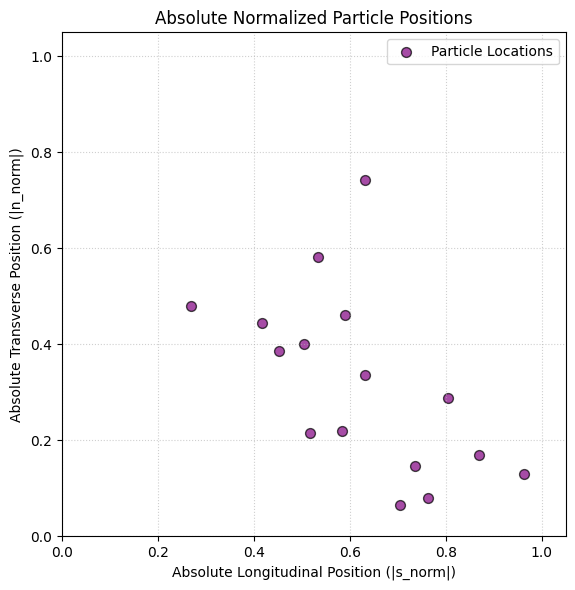

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# --- 1. Load the Processed Points CSV ---
output_csv = "processed_poiny.csv"

# Load without headers as specified in previous steps
# Columns: [source_trajectory, frame, s_norm, n_norm]
df = pd.read_csv(output_csv, header=None, names=['source_trajectory', 'frame', 's_norm', 'n_norm'])

# --- 2. Extract Absolute Values for Normalized Coordinates ---
abs_s_norm = df['s_norm'].abs()
abs_n_norm = df['n_norm'].abs()

# --- 3. Plot Absolute Normalized Coordinates [0, 1] x [0, 1] ---
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(abs_s_norm, abs_n_norm, color='purple', alpha=0.7, edgecolors='k', s=50, label='Particle Locations')

# Formatting bounds strictly from 0 to 1
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.set_aspect('equal')

ax.set_title("Absolute Normalized Particle Positions")
ax.set_xlabel("Absolute Longitudinal Position (|s_norm|)")
ax.set_ylabel("Absolute Transverse Position (|n_norm|)")

ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

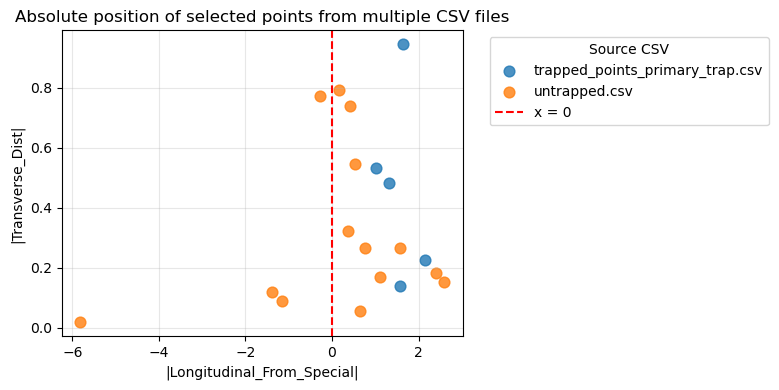

In [57]:
# -----------------------------
# Scatterplot: absolute longitudinal vs absolute transverse
# Different CSV files are plotted as different groups
# -----------------------------

from click import group


x_col = "abs_Longitudinal_From_Special"
y_col = "abs_Transverse_Dist"

plt.figure(figsize=(8, 4))

color_map = {
    "trapped_points_primary_trap.csv": "red",
    "trapped_points_secondary trapped.csv": "blue",
    "untrapped.csv": "black",
    "0824_trapped.csv": "yellow",
    "0824_untrapped.csv": "orange",
}


for group_file, group_df in combined_df.groupby("group_file"):
    plt.scatter(
        group_df[x_col],
        group_df[y_col],
        s=60,
        alpha=0.8,
        label=group_file,
        #change color based on source file
        #color=color_map[group_file]
    )

# Red dashed vertical reference line at x = 0
plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="x = 0"
)

plt.xlabel("|Longitudinal_From_Special|")
plt.ylabel("|Transverse_Dist|")
plt.title("Absolute position of selected points from multiple CSV files")

plt.legend(
    title="Source CSV",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

Parent folders found:
D:\Dharaneeswar\data\1-1 Masks\854-1085
D:\Dharaneeswar\data\2-1 Masks\129-471
D:\Dharaneeswar\data\3-2 Masks\144-482
D:\Dharaneeswar\data\3-3 Masks\particle_1
D:\Dharaneeswar\data\3-3 Masks\particle_2
D:\Dharaneeswar\data\1-1 Masks\44-60
D:\Dharaneeswar\data\1-1 Masks\172-181
D:\Dharaneeswar\data\1-1 Masks\215-232
D:\Dharaneeswar\data\1-1 Masks\279-296
D:\Dharaneeswar\data\1-1 Masks\344-360
D:\Dharaneeswar\data\1-1 Masks\401-418
D:\Dharaneeswar\data\1-1 Masks\446-463
D:\Dharaneeswar\data\1-1 Masks\671-687
D:\Dharaneeswar\data\1-1 Masks\718-736
D:\Dharaneeswar\data\1-1 Masks\760-778
D:\Dharaneeswar\data\1-1 Masks\1126-1145
D:\Dharaneeswar\data\1-1 Masks\1168-1187
D:\Dharaneeswar\data\1-1 Masks\1232-1249
D:\Dharaneeswar\data\2-1 Masks\30-45


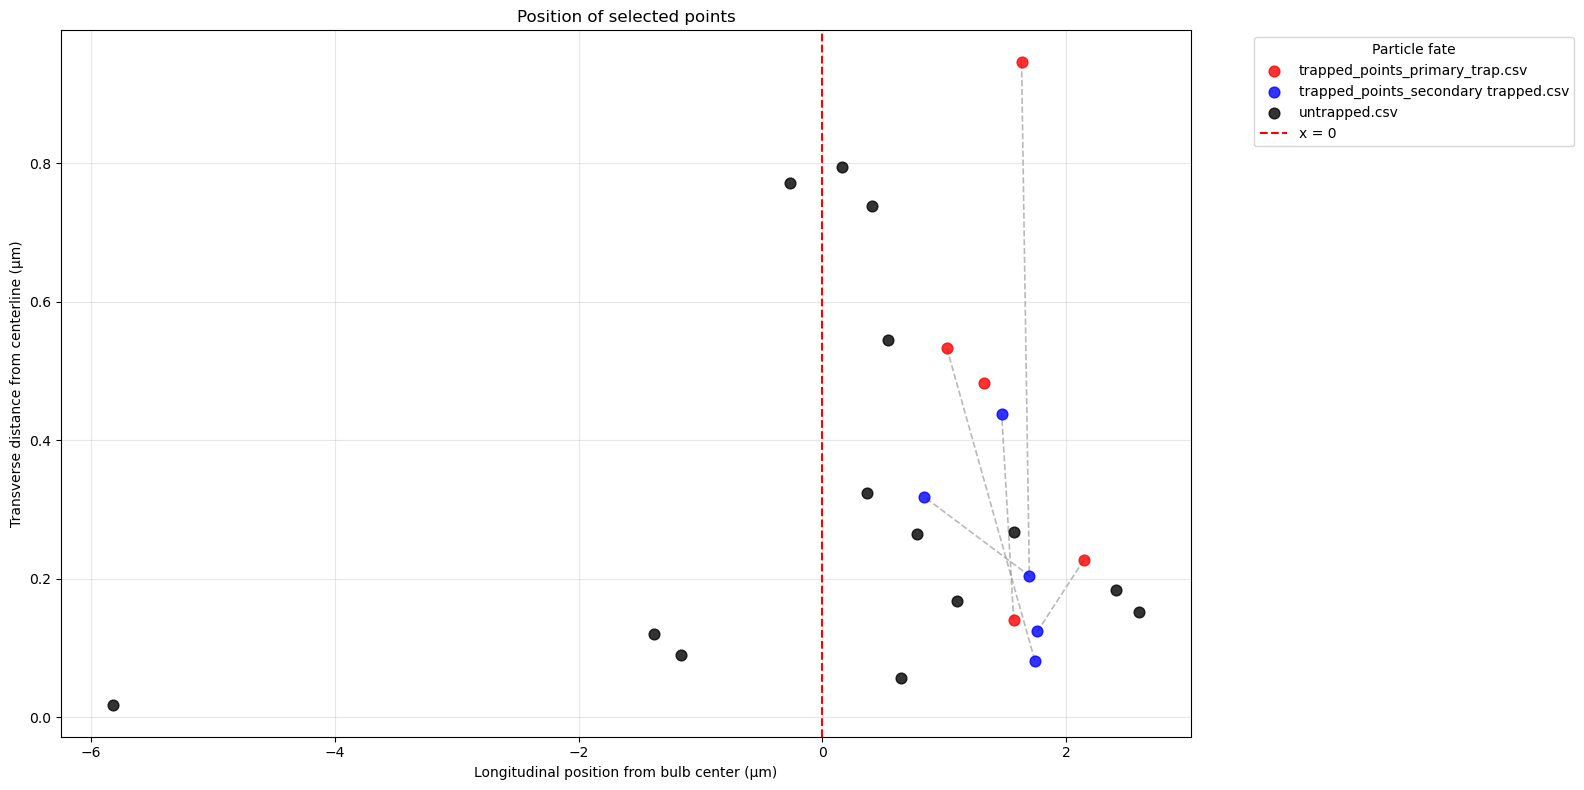

In [39]:
from pathlib import PureWindowsPath

# -----------------------------
# Scatterplot:
# - point color = biological group
# - dashed lines connect ALL points whose source_csv
#   comes from the same parent folder
# -----------------------------

x_col = "abs_Longitudinal_From_Special"
y_col = "abs_Transverse_Dist"


# ------------------------------------------------------------
# Extract parent folder from source_csv
# ------------------------------------------------------------

combined_df["source_parent_folder"] = combined_df["source_csv"].apply(
    lambda x: str(PureWindowsPath(str(x)).parent)
)

# Optional: just the folder name, useful for checking
combined_df["source_parent_name"] = combined_df["source_csv"].apply(
    lambda x: PureWindowsPath(str(x)).parent.name
)


print("Parent folders found:")
for folder in combined_df["source_parent_folder"].unique():
    print(folder)


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(figsize=(16, 8))

color_map = {
    "trapped_points_primary_trap.csv": "red",
    "trapped_points_secondary trapped.csv": "blue",
    "untrapped.csv": "black",
}


# ------------------------------------------------------------
# 1. Plot dots according to biological group
# ------------------------------------------------------------

for group_file, group_df in combined_df.groupby("group_file"):

    color = color_map.get(group_file, "gray")

    plt.scatter(
        group_df[x_col],
        group_df[y_col],
        s=60,
        alpha=0.8,
        label=group_file,
        color=color,
        zorder=3
    )


# ------------------------------------------------------------
# 2. Connect all points from the SAME parent folder
#    regardless of source_csv or biological group
# ------------------------------------------------------------

for parent_folder, trajectory_df in combined_df.groupby(
    "source_parent_folder"
):

    if len(trajectory_df) < 2:
        continue

    # Connect points chronologically
    trajectory_df = trajectory_df.sort_values("Frame")

    plt.plot(
        trajectory_df[x_col],
        trajectory_df[y_col],
        linestyle="--",
        linewidth=1.2,
        alpha=0.55,
        color="gray",
        zorder=1
    )


# ------------------------------------------------------------
# Reference line
# ------------------------------------------------------------

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="x = 0"
)

plt.xlabel("Longitudinal position from bulb center (µm)")
plt.ylabel("Transverse distance from centerline (µm)")
plt.title("Position of selected points")

plt.legend(
    title="Particle fate",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

try plot Rho


In [37]:
# ============================================================
# RHO CELL 1
# Select and load consensus lumen boundary
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import tkinter as tk
from tkinter import filedialog


root = tk.Tk()
root.withdraw()
root.attributes("-topmost", True)

boundary_path = filedialog.askopenfilename(
    title="Select consensus lumen boundary",
    filetypes=[
        ("Consensus boundary", "*.csv *.npz"),
        ("CSV files", "*.csv"),
        ("NumPy archive", "*.npz"),
        ("All files", "*.*")
    ]
)

root.destroy()

if not boundary_path:
    raise FileNotFoundError("No consensus boundary file selected.")

boundary_path = Path(boundary_path)


# ------------------------------------------------------------
# Load CSV or NPZ
# ------------------------------------------------------------

if boundary_path.suffix.lower() == ".csv":

    boundary_df = pd.read_csv(boundary_path)

elif boundary_path.suffix.lower() == ".npz":

    b = np.load(boundary_path, allow_pickle=False)

    boundary_df = pd.DataFrame({
        "s_um": b["s_um"],
        "lower_y_um": b["lower_y_um"],
        "upper_y_um": b["upper_y_um"],
        "midpoint_y_um": b["midpoint_y_um"],
        "half_width_um": b["half_width_um"],
        "width_um": b["width_um"],
    })

else:
    raise ValueError(
        "Boundary file must be consensus_lumen_boundary.csv "
        "or consensus_lumen_boundary.npz"
    )


# ------------------------------------------------------------
# Keep only valid boundary positions
# ------------------------------------------------------------

required_boundary_cols = [
    "s_um",
    "lower_y_um",
    "upper_y_um",
    "midpoint_y_um",
    "half_width_um",
]

missing = [
    c for c in required_boundary_cols
    if c not in boundary_df.columns
]

if missing:
    raise ValueError(
        f"Boundary file is missing columns: {missing}"
    )


boundary_df = boundary_df.copy()

for col in required_boundary_cols:
    boundary_df[col] = pd.to_numeric(
        boundary_df[col],
        errors="coerce"
    )

boundary_valid = (
    boundary_df
    .dropna(subset=[
        "s_um",
        "lower_y_um",
        "upper_y_um",
        "half_width_um"
    ])
    .sort_values("s_um")
    .reset_index(drop=True)
)

boundary_valid = boundary_valid[
    boundary_valid["half_width_um"] > 0
].copy()


print("Loaded boundary:")
print(boundary_path)

print(
    f"Valid s range: "
    f"{boundary_valid['s_um'].min():.3f} to "
    f"{boundary_valid['s_um'].max():.3f} µm"
)

display(boundary_valid.head())

Loaded boundary:
C:\Users\zhr61\Downloads\consensus_lumen_boundary_0824.csv
Valid s range: -6.880 to 6.760 µm


,s_um,s_pixel,lower_y_um,upper_y_um,midpoint_y_um,half_width_um,width_um,lower_y_pixel,upper_y_pixel,midpoint_y_pixel,half_width_pixel,lower_q25_um,lower_q75_um,upper_q25_um,upper_q75_um,n_valid_traces
0,-6.88,-172.0,-0.433285,0.427865,-0.002710,0.430575,0.861150,-10.832121,10.696619,-0.067751,10.764370,-0.501879,-0.364691,0.380284,0.475445,2
1,-6.84,-171.0,-0.433257,0.431298,-0.000980,0.432278,0.864556,-10.831437,10.782455,-0.024491,10.806946,-0.501313,-0.365202,0.384672,0.477925,2
2,-6.80,-170.0,-0.433170,0.435113,0.000972,0.434141,0.868283,-10.829238,10.877837,0.024299,10.853537,-0.500572,-0.365767,0.389464,0.480762,2
3,-6.76,-169.0,-0.433046,0.439164,0.003059,0.436105,0.872210,-10.826155,10.979106,0.076476,10.902631,-0.499734,-0.366358,0.394481,0.483848,2
4,-6.72,-168.0,-0.432923,0.443369,0.005223,0.438146,0.876292,-10.823077,11.084226,0.130574,10.953651,-0.498876,-0.366970,0.399628,0.487110,2


Cell 2 — Convert particle coordinates and interpolate local lumen width

This cell deliberately gives you two calibration switches:

S_DIRECTION = 1.0
S_OFFSET_UM = 0.0

Normally leave them as shown.

If your boundary runs anterior→posterior in the opposite direction from your particle coordinate, change:

S_DIRECTION = -1.0

If the two definitions of bulb center are displaced by, for example, 0.25 μm, adjust S_OFFSET_UM.

In [38]:
# ============================================================
# RHO CELL 2
# Put particle positions into boundary coordinates
# and interpolate local lumen geometry
# ============================================================

UM_PER_PIXEL = 0.04


# ------------------------------------------------------------
# Coordinate alignment
# ------------------------------------------------------------
#
# Leave these at default if:
#   particle x = 0
# and
#   boundary s = 0
#
# correspond to the same anterior-bulb center.
#
# Change S_DIRECTION to -1 if anterior/posterior is reversed.
#
# S_OFFSET_UM can correct a small systematic offset between
# the two definitions of bulb center.
# ------------------------------------------------------------

S_DIRECTION = 1.0
S_OFFSET_UM = 0.0

# Set to True when the boundary file labels the upper and lower
# geometry in reverse. This swaps the two complete curves.
SWAP_UPPER_LOWER_GEOMETRY = True


rho_df = combined_df.copy()


# Original particle coordinates are in pixels
rho_df["particle_s_um_raw"] = (
    pd.to_numeric(
        rho_df["Longitudinal_From_Special"],
        errors="coerce"
    )
    * UM_PER_PIXEL
)

rho_df["particle_y_um"] = (
    pd.to_numeric(
        rho_df["Transverse_Dist"],
        errors="coerce"
    )
    * UM_PER_PIXEL
)


# Convert longitudinal particle coordinate into the
# coordinate system of the consensus boundary
rho_df["particle_s_um"] = (
    S_DIRECTION * rho_df["particle_s_um_raw"]
    + S_OFFSET_UM
)


# ------------------------------------------------------------
# Interpolation helper
# ------------------------------------------------------------

s_boundary = boundary_valid["s_um"].to_numpy()

lower_boundary = boundary_valid["lower_y_um"].to_numpy()
upper_boundary = boundary_valid["upper_y_um"].to_numpy()
mid_boundary = boundary_valid["midpoint_y_um"].to_numpy()
half_width_boundary = boundary_valid["half_width_um"].to_numpy()


# Ensure all boundary arrays are sorted by s, then optionally swap
# the complete upper and lower curves when the file labels are reversed.
# ---------------------------------------------------------------------
order = np.argsort(s_boundary)
s_boundary = s_boundary[order]
upper_boundary = upper_boundary[order]
lower_boundary = lower_boundary[order]
mid_boundary = mid_boundary[order]
half_width_boundary = half_width_boundary[order]

if SWAP_UPPER_LOWER_GEOMETRY:
    upper_boundary, lower_boundary = -lower_boundary.copy(), -upper_boundary.copy()
    print("SWAP_UPPER_LOWER_GEOMETRY=True: swapped upper/lower curves")

# Validate the chosen orientation instead of silently undoing the switch.
invalid_orientation = upper_boundary <= lower_boundary
if np.any(invalid_orientation):
    raise ValueError(
        f"Upper boundary is not above lower boundary at "
        f"{np.sum(invalid_orientation)} position(s). Toggle "
        f"SWAP_UPPER_LOWER_GEOMETRY and rerun this cell."
    )

# Recompute derived arrays and invalidate non-positive widths
mid_boundary = 0.5 * (upper_boundary + lower_boundary)
half_width_boundary = 0.5 * (upper_boundary - lower_boundary)
half_width_boundary[~np.isfinite(half_width_boundary) | (half_width_boundary <= 0)] = np.nan


def interpolate_inside_boundary(query_s, source_s, source_value):
    """
    np.interp normally extrapolates using endpoint values.
    We do NOT want that here.

    Positions outside the measured lumen template become NaN.
    """

    query_s = np.asarray(query_s, dtype=float)

    result = np.interp(
        query_s,
        source_s,
        source_value
    )

    outside = (
        (query_s < source_s.min()) |
        (query_s > source_s.max())
    )

    result[outside] = np.nan

    return result


rho_df["local_lower_y_um"] = interpolate_inside_boundary(
    rho_df["particle_s_um"],
    s_boundary,
    lower_boundary
)

rho_df["local_upper_y_um"] = interpolate_inside_boundary(
    rho_df["particle_s_um"],
    s_boundary,
    upper_boundary
)

rho_df["local_midpoint_y_um"] = interpolate_inside_boundary(
    rho_df["particle_s_um"],
    s_boundary,
    mid_boundary
)

rho_df["local_half_width_um"] = interpolate_inside_boundary(
    rho_df["particle_s_um"],
    s_boundary,
    half_width_boundary
)


print(f"Total particle points: {len(rho_df)}")

print(
    "Points inside consensus-boundary s range:",
    rho_df["local_half_width_um"].notna().sum()
)

display(
    rho_df[
        [
            "source_file",
            "particle_s_um",
            "particle_y_um",
            "local_half_width_um"
        ]
    ].head()
)


SWAP_UPPER_LOWER_GEOMETRY=True: swapped upper/lower curves
Total particle points: 24
Points inside consensus-boundary s range: 24


,source_file,particle_s_um,particle_y_um,local_half_width_um
0,trajectory_854-1085.csv,1.633159,0.945905,1.832159
1,trajectory_129-471.csv,1.328512,0.482944,1.964017
2,trajectory_trapped_225.csv,2.144002,0.227064,1.552023
3,trajectory_trapped_79.csv,1.020312,0.533032,2.068209
4,trajectory_aligned_316.csv,1.568642,0.140067,1.862158


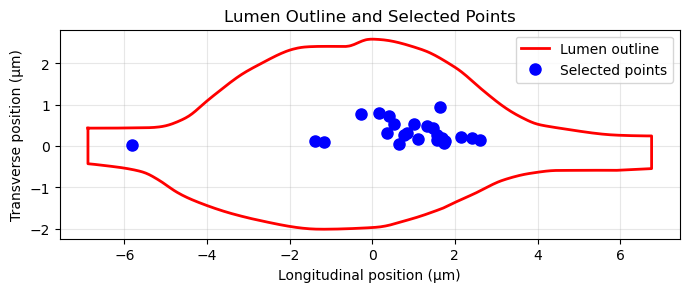

In [39]:

# Plot the outline of the lumen and the selected points in boundary coordinates
# Build a closed outline from upper and lower boundary arrays
upper = np.column_stack((s_boundary, upper_boundary))
lower = np.column_stack((s_boundary[::-1], lower_boundary[::-1]))
# Close the polygon by repeating the first point
lumen_outline = np.vstack([upper, lower, upper[:1]])

# Selected points from rho_df (particle_s_um, particle_y_um)
selected_points = (
    rho_df[["particle_s_um", "particle_y_um"]]
    .dropna()
    .to_numpy()
)

plt.figure(figsize=(8, 4))
plt.plot(lumen_outline[:, 0], lumen_outline[:, 1], 'r-', linewidth=2, label='Lumen outline')

if selected_points.size:
    plt.plot(selected_points[:, 0], selected_points[:, 1], 'bo', markersize=8, label='Selected points')
else:
    plt.gca().text(0.5, 0.5, 'No selected points available', transform=plt.gca().transAxes, ha='center')

plt.xlabel('Longitudinal position (µm)')
plt.ylabel('Transverse position (µm)')
plt.title('Lumen Outline and Selected Points')
plt.gca().set_aspect('equal', adjustable='box')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Cell 3 — Calculate ρ

For your current Figure 3, I would initially use the absolute centerline-normalized value:

ρ
abs=
R(sp)/yp	​

	​

.

In [31]:
# ============================================================
# RHO CELL 3
# Calculate normalized transverse position rho
# ============================================================


# ------------------------------------------------------------
# Recommended first definition:
#
# rho = |transverse deviation from centerline|
#       --------------------------------------
#            local lumen half-width
#
# rho = 0   -> centerline
# rho = 1   -> consensus lumen wall
# ------------------------------------------------------------

rho_df["abs_particle_y_um"] = np.abs(
    rho_df["particle_y_um"]
)

rho_df["rho"] = (
    rho_df["abs_particle_y_um"]
    /
    rho_df["local_half_width_um"]
)


# Invalid values
rho_df.loc[
    (~np.isfinite(rho_df["rho"])) |
    (rho_df["local_half_width_um"] <= 0),
    "rho"
] = np.nan


# ------------------------------------------------------------
# QC flags
# ------------------------------------------------------------

rho_df["inside_boundary_longitudinal_range"] = (
    rho_df["local_half_width_um"].notna()
)

rho_df["rho_above_1"] = (
    rho_df["rho"] > 1
)


print("Valid rho values:", rho_df["rho"].notna().sum())

print(
    "Points with rho > 1:",
    rho_df["rho_above_1"].sum()
)

print()
print("rho summary:")
display(rho_df["rho"].describe())


# Show any suspicious points
outside_wall = rho_df[
    rho_df["rho_above_1"]
]

if len(outside_wall) > 0:
    print("Points with rho > 1:")
    display(
        outside_wall[
            [
                "source_file",
                "particle_s_um",
                "particle_y_um",
                "local_half_width_um",
                "rho"
            ]
        ]
    )

Valid rho values: 11
Points with rho > 1: 5

rho summary:


count    11.000000
mean      0.955750
std       0.748231
min       0.153210
25%       0.421722
50%       0.555377
75%       1.329059
max       2.491900
Name: rho, dtype: float64

Points with rho > 1:


,source_file,particle_s_um,particle_y_um,local_half_width_um,rho
1,trajectory_50-111.csv,-1.495079,3.535932,2.204702,1.603814
2,trajectory_56-130.csv,-0.242139,2.273936,2.264488,1.004172
4,trajectory_10-20.csv,3.202844,1.668379,0.875016,1.906684
6,trajectory_34-44.csv,0.170424,2.391684,2.268496,1.054304
8,trajectory_23-33.csv,5.043265,1.176564,0.472155,2.491900


**Cell 4 — Plot longitudinal position vs ρ, and export**

This produces essentially the normalized version of your existing Figure 3.

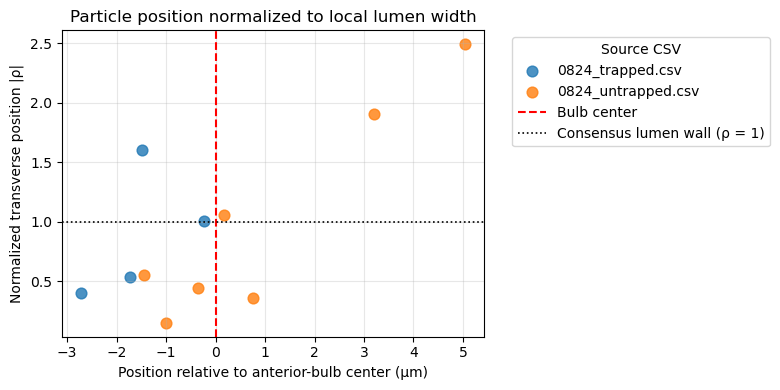

Saved:
C:\Users\zhr61\Downloads\selected_points_with_rho.csv


In [32]:
# ============================================================
# RHO CELL 4
# Plot particle longitudinal position versus rho
# and export calculated values
# ============================================================

plot_df = rho_df.dropna(
    subset=[
        "particle_s_um",
        "rho"
    ]
).copy()


plt.figure(figsize=(8, 4))


for group_file, group_df in plot_df.groupby("group_file"):

    plt.scatter(
        group_df["particle_s_um"],
        group_df["rho"],
        s=60,
        alpha=0.8,
        label=group_file
    )


# Bulb center
plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Bulb center"
)


# Consensus wall
plt.axhline(
    y=1,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="Consensus lumen wall (ρ = 1)"
)


plt.xlabel(
    "Position relative to anterior-bulb center (µm)"
)

plt.ylabel(
    "Normalized transverse position |ρ|"
)

plt.title(
    "Particle position normalized to local lumen width"
)


plt.legend(
    title="Source CSV",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# Export calculated rho data
# ------------------------------------------------------------

output_rho_csv = (
    boundary_path.parent
    / "selected_points_with_rho.csv"
)

rho_df.to_csv(
    output_rho_csv,
    index=False
)

print("Saved:")
print(output_rho_csv)